In [1]:
import pandas as pd

In [2]:
telo_a = pd.read_sas("../data/TELO_A.xpt")

In [3]:
telo_b = pd.read_sas("../data/TELO_B.xpt")

In [4]:
dnam = pd.read_sas("../data/dnmepi.sas7bdat")

In [5]:
telo_a.head()

,SEQN,TELOMEAN,TELOSTD
0,884.0,NaN,NaN
1,2007.0,NaN,NaN
2,6548.0,NaN,NaN
3,2084.0,0.389337,0.027500
4,6445.0,0.433244,0.018915


In [6]:
telo_b.head()

,SEQN,TELOMEAN,TELOSTD
0,10943.0,NaN,NaN
1,11695.0,NaN,NaN
2,11995.0,NaN,NaN
3,12697.0,NaN,NaN
4,12745.0,NaN,NaN


In [7]:
dnam.head()

,SEQN,XY_Estimation,HorvathAge,HannumAge,SkinBloodAge,PhenoAge,GDF15Mort,B2MMort,CystatinCMort,TIMP1Mort,...,WeidnerAge,VidalBraloAge,DunedinPoAm,CD8TPP,CD4TPP,Nkcell,Bcell,MonoPP,NeuPP,WTDN4YR
0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,7.0,1.0,62.484906,43.790026,50.977392,31.965868,810.940037,1545146.137,570694.3868,32937.37877,...,28.065671,47.692927,1.051665,0.182236,0.221193,0.064178,0.128408,0.077392,0.425682,20752.885955
2,13.0,2.0,76.119340,78.857218,69.883279,73.680914,1127.296957,1768383.141,694439.3696,37740.30988,...,53.724741,65.234027,1.145963,0.053556,0.052008,0.038131,0.007778,0.043408,0.850470,1260.059101
3,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
4,16.0,1.0,80.204158,77.042360,81.737482,67.810727,1190.042227,1951256.905,633099.8724,34858.26081,...,62.532134,65.920700,1.117623,0.061493,0.176275,0.081518,0.049638,0.052985,0.636939,13383.476924


In [8]:
print("TELO_A valid:", telo_a["TELOMEAN"].notna().sum())
print("TELO_B valid:", telo_b["TELOMEAN"].notna().sum())

TELO_A valid: 3567
TELO_B valid: 4260


In [9]:
print([c for c in dnam.columns if "telo" in c.lower()])

['HorvathTelo']


In [10]:
print("DNAm telomere valid:", dnam["HorvathTelo"].notna().sum())

DNAm telomere valid: 2532


In [11]:
telo = pd.concat([telo_a, telo_b], ignore_index=True)
telo.shape

(7839, 3)

In [12]:
telo.head()

,SEQN,TELOMEAN,TELOSTD
0,884.0,NaN,NaN
1,2007.0,NaN,NaN
2,6548.0,NaN,NaN
3,2084.0,0.389337,0.027500
4,6445.0,0.433244,0.018915


In [14]:
telo_valid = telo.dropna(subset=["TELOMEAN"])
telo_valid.shape

(7827, 3)

In [15]:
dnam_telo = dnam[["SEQN", "HorvathTelo"]].dropna(subset=["HorvathTelo"])
dnam_telo.head()

,SEQN,HorvathTelo
1,7.0,7.346313
2,13.0,6.265380
4,16.0,6.745862
7,40.0,6.491756
8,46.0,6.187070


In [16]:
merged = pd.merge(
    telo_valid,
    dnam_telo,
    on="SEQN",
    how="inner"
)
merged.shape

(2530, 4)

In [17]:
merged.head()

,SEQN,TELOMEAN,TELOSTD,HorvathTelo
0,2084.0,0.389337,0.027500,6.016263
1,6445.0,0.433244,0.018915,5.608514
2,5363.0,0.443293,0.041010,5.970685
3,8606.0,0.444447,0.046839,5.903165
4,5843.0,0.453036,0.015954,6.119856


In [18]:
merged.describe()

,SEQN,TELOMEAN,TELOSTD,HorvathTelo
count,2530.000000,2530.000000,2530.000000,2530.000000
mean,10400.566798,0.926132,0.060859,6.568395
std,6045.665634,0.225699,0.050395,0.313821
min,7.000000,0.389337,0.002904,5.296396
25%,5252.250000,0.769877,0.039699,6.368471
50%,10368.500000,0.893990,0.054440,6.580448
75%,15548.750000,1.053043,0.073375,6.774408
max,20995.000000,2.363065,1.785815,7.750052


In [19]:
merged["SEQN"].duplicated().sum()

np.int64(0)

In [20]:
merged[["TELOMEAN", "HorvathTelo"]].corr()

,TELOMEAN,HorvathTelo
TELOMEAN,1.00000,0.36917
HorvathTelo,0.36917,1.00000


In [23]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


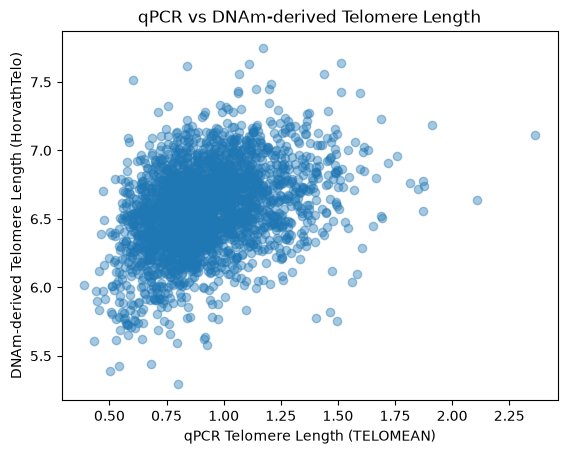

In [24]:
plt.scatter(
    merged["TELOMEAN"],
    merged["HorvathTelo"],
    alpha=0.4
)

plt.xlabel("qPCR Telomere Length (TELOMEAN)")
plt.ylabel("DNAm-derived Telomere Length (HorvathTelo)")
plt.title("qPCR vs DNAm-derived Telomere Length")

plt.show()

In [26]:
demo_a = pd.read_sas("../data/DEMO.xpt")
demo_b = pd.read_sas("../data/DEMO_B.xpt")

In [27]:
demo_a[["SEQN", "RIDAGEYR"]].head()

,SEQN,RIDAGEYR
0,1.0,2.0
1,2.0,77.0
2,3.0,10.0
3,4.0,1.0
4,5.0,49.0


In [28]:
demo_b[["SEQN", "RIDAGEYR"]].head()

,SEQN,RIDAGEYR
0,9966.0,39.0
1,9967.0,23.0
2,9968.0,84.0
3,9969.0,51.0
4,9970.0,16.0


In [29]:
demo_all = pd.concat([demo_a, demo_b], ignore_index=True)

In [30]:
demo_age = demo_all[["SEQN", "RIDAGEYR"]]

In [31]:
merged_age = pd.merge(
    merged,
    demo_age,
    on="SEQN",
    how="inner"
)
merged_age.shape

(2530, 5)

In [32]:
merged_age["RIDAGEYR"].isna().sum()

np.int64(0)

In [33]:
merged_age["RIDAGEYR"].describe()

count    2530.000000
mean       66.125296
std        10.074756
min        50.000000
25%        58.000000
50%        65.000000
75%        74.000000
max        85.000000
Name: RIDAGEYR, dtype: float64

In [34]:
merged_age[["RIDAGEYR", "TELOMEAN", "HorvathTelo"]].corr()

,RIDAGEYR,TELOMEAN,HorvathTelo
RIDAGEYR,1.000000,-0.253848,-0.581506
TELOMEAN,-0.253848,1.000000,0.369170
HorvathTelo,-0.581506,0.369170,1.000000


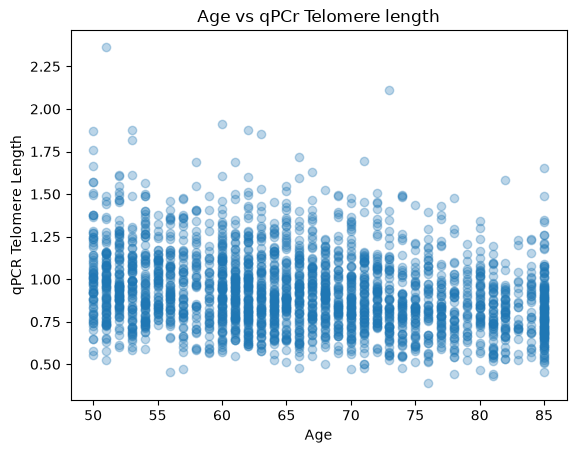

In [38]:
plt.scatter(
    merged_age["RIDAGEYR"],
    merged_age["TELOMEAN"],
    alpha=0.3
)

plt.xlabel("Age")
plt.ylabel("qPCR Telomere Length")
plt.title("Age vs qPCr Telomere length")
plt.show()

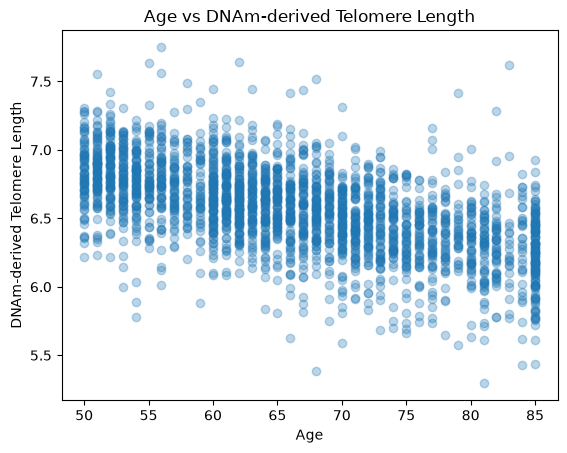

In [39]:
plt.scatter(
    merged_age["RIDAGEYR"],
    merged_age["HorvathTelo"],
    alpha=0.3
)
plt.xlabel("Age")
plt.ylabel("DNAm-derived Telomere Length")
plt.title("Age vs DNAm-derived Telomere Length")
plt.show()

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
age = merged_age[["RIDAGEYR"]]

qpcr_model = LinearRegression()
qpcr_model.fit(age, merged_age["TELOMEAN"])

merged_age["qPCR_age_pred"] = qpcr_model.predict(age)

merged_age["qPCR_residual"] = (
    merged_age["TELOMEAN"] - merged_age["qPCR_age_pred"]
)

In [44]:
dnam_model = LinearRegression()
dnam_model.fit(age, merged_age["HorvathTelo"])

merged_age["DNAm_age_pred"] = dnam_model.predict(age)

merged_age["DNAm_residual"] = (
    merged_age["HorvathTelo"]- merged_age["DNAm_age_pred"]
)

In [45]:
merged_age[
    [
        "RIDAGEYR",
        "TELOMEAN",
        "qPCR_age_pred",
        "qPCR_residual",
        "HorvathTelo",
        "DNAm_age_pred",
        "DNAm_residual"
    ]
].head()

,RIDAGEYR,TELOMEAN,qPCR_age_pred,qPCR_residual,HorvathTelo,DNAm_age_pred,DNAm_residual
0,76.0,0.389337,0.869977,-0.480640,6.016263,6.389530,-0.373267
1,81.0,0.433244,0.841543,-0.408299,5.608514,6.298962,-0.690448
2,81.0,0.443293,0.841543,-0.398250,5.970685,6.298962,-0.328277
3,78.0,0.444447,0.858603,-0.414156,5.903165,6.353303,-0.450137
4,56.0,0.453036,0.983713,-0.530677,6.119856,6.751799,-0.631943


In [50]:
pd.options.display.float_format = "{:.6f}".format

merged_age[
    ["RIDAGEYR", "qPCR_residual", "DNAm_residual"]
].corr()

,RIDAGEYR,qPCR_residual,DNAm_residual
RIDAGEYR,1.000000,0.000000,0.000000
qPCR_residual,0.000000,1.000000,0.281558
DNAm_residual,0.000000,0.281558,1.000000


In [51]:
merged_age["qPCR_z"] = (
    merged_age["qPCR_residual"] - merged_age["qPCR_residual"].mean()
) / merged_age["qPCR_residual"].std()

merged_age["DNAm_z"] = (
    merged_age["DNAm_residual"] - merged_age["DNAm_residual"].mean()
) / merged_age["DNAm_residual"].std()


In [52]:
merged_age[["qPCR_z", "DNAm_z"]].describe()

,qPCR_z,DNAm_z
count,2530.000000,2530.000000
mean,-0.000000,-0.000000
std,1.000000,1.000000
min,-2.430887,-4.498168
25%,-0.683383,-0.597114
50%,-0.124004,0.008893
75%,0.556389,0.631168
max,6.188193,5.308285


In [53]:
merged_age["discordance_signed"] = (
    merged_age["qPCR_z"] - merged_age["DNAm_z"]
)

merged_age["discordance"] = merged_age["discordance_signed"].abs()

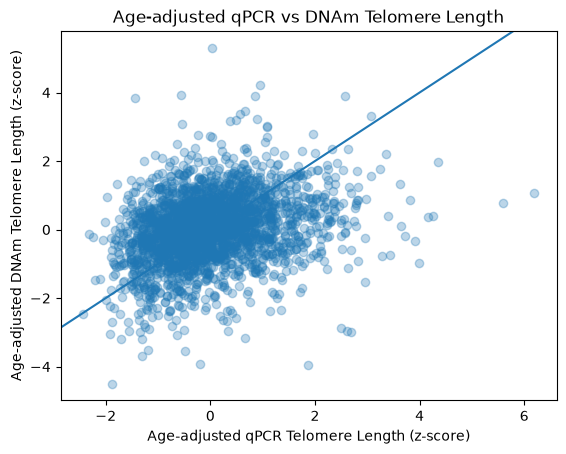

In [54]:
plt.scatter(
    merged_age["qPCR_z"],
    merged_age["DNAm_z"],
    alpha=0.3
)

plt.xlabel("Age-adjusted qPCR Telomere Length (z-score)")
plt.ylabel("Age-adjusted DNAm Telomere Length (z-score)")
plt.title("Age-adjusted qPCR vs DNAm Telomere Length")

plt.axline((0,0), slope=1)

plt.show()

In [55]:
merged_age[
    ["qPCR_z", "DNAm_z", "discordance_signed", "discordance"]
].describe()

,qPCR_z,DNAm_z,discordance_signed,discordance
count,2530.000000,2530.000000,2530.000000,2530.000000
mean,-0.000000,-0.000000,-0.000000,0.917618
std,1.000000,1.000000,1.198701,0.771057
min,-2.430887,-4.498168,-5.277861,0.000362
25%,-0.683383,-0.597114,-0.775666,0.352175
50%,-0.124004,0.008893,-0.051886,0.742062
75%,0.556389,0.631168,0.685957,1.273478
max,6.188193,5.308285,5.818515,5.818515


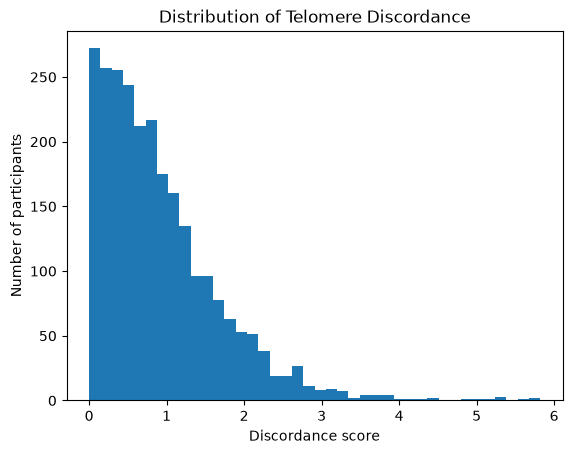

In [56]:
plt.hist(
    merged_age["discordance"],
    bins=40
)

plt.xlabel("Discordance score")
plt.ylabel("Number of participants")
plt.title("Distribution of Telomere Discordance")

plt.show()

In [57]:
merged_age["discordance"].describe(
percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count   2530.000000
mean       0.917618
std        0.771057
min        0.000362
50%        0.742062
75%        1.273478
90%        1.934918
95%        2.337151
99%        3.494987
max        5.818515
Name: discordance, dtype: float64

In [58]:
merged_age.nlargest(
    10,
    "discordance"
)[
    [
        "SEQN",
        "RIDAGEYR",
        "TELOMEAN",
        "TELOSTD",
        "HorvathTelo",
        "qPCR_z",
        "DNAm_z",
        "discordance_signed",
        "discordance"
    ]
]

,SEQN,RIDAGEYR,TELOMEAN,TELOSTD,HorvathTelo,qPCR_z,DNAm_z,discordance_signed,discordance
1194,6383.000000,54.000000,1.402851,0.077045,5.779399,1.867861,-3.950653,5.818515,5.818515
1203,3690.000000,69.000000,1.496372,0.088782,5.751156,2.686999,-2.997058,5.684057,5.684057
2515,17260.000000,54.000000,1.563573,0.121167,6.035391,2.604086,-2.947966,5.552052,5.552052
1199,9401.000000,67.000000,1.466694,0.113494,5.816987,2.498952,-2.881103,5.380056,5.380056
1249,11311.000000,68.000000,0.601550,0.062915,7.514781,-1.437989,3.839871,-5.277861,5.277861
550,6121.000000,83.000000,0.837457,0.057053,7.617975,0.033386,5.308285,-5.274899,5.274899
2529,10449.000000,51.000000,2.363065,0.209445,7.115244,6.188193,1.068826,5.119367,5.119367
2528,12960.000000,53.000000,1.873468,0.069311,6.554100,3.997581,-0.987203,4.984784,4.984784
1219,8532.000000,73.000000,2.109059,0.105996,6.638565,5.597753,0.762593,4.835160,4.835160
257,917.000000,82.000000,0.711588,0.081272,7.281105,-0.569237,3.917863,-4.487100,4.487100


In [60]:
merged_age[["TELOSTD", "discordance"]].corr()

,TELOSTD,discordance
TELOSTD,1.000000,0.135375
discordance,0.135375,1.000000


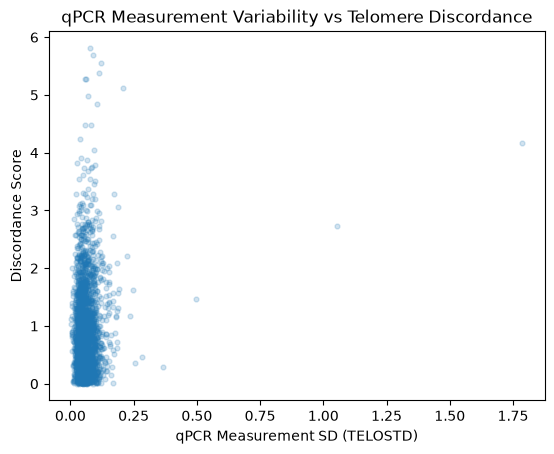

In [61]:
plt.scatter(
    merged_age["TELOSTD"],
    merged_age["discordance"],
    alpha=0.2,
    s=12
)

plt.xlabel("qPCR Measurement SD (TELOSTD)")
plt.ylabel("Discordance Score")
plt.title("qPCR Measurement Variability vs Telomere Discordance")

plt.show()

In [62]:
merged_age[["TELOSTD", "discordance"]].corr(method="spearman")

,TELOSTD,discordance
TELOSTD,1.000000,0.062812
discordance,0.062812,1.000000


In [63]:
merged_age["TELOSTD"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
)

count   2530.000000
mean       0.060859
std        0.050395
min        0.002904
50%        0.054440
90%        0.096210
95%        0.111288
99%        0.168941
max        1.785815
Name: TELOSTD, dtype: float64

In [64]:
cutoff = merged_age["TELOSTD"].quantile(0.99)

qc_data = merged_age[
    merged_age["TELOSTD"] <= cutoff
]

qc_data[["TELOSTD", "discordance"]].corr()

,TELOSTD,discordance
TELOSTD,1.000000,0.078183
discordance,0.078183,1.000000


In [65]:
merged_age["TELO_CV"] = (
    merged_age["TELOSTD"] / merged_age["TELOMEAN"]
)

In [66]:
merged_age[["TELO_CV", "discordance"]].corr()

,TELO_CV,discordance
TELO_CV,1.000000,0.069419
discordance,0.069419,1.000000


In [67]:
merged_age[["TELO_CV", "discordance"]].corr(method="spearman")

,TELO_CV,discordance
TELO_CV,1.000000,0.022503
discordance,0.022503,1.000000


In [68]:
merged_age.to_csv("../data/processed_telomere_core.csv", index=False)